<a href="https://colab.research.google.com/github/USHA2003-47/MANAPURAM-USHA-KIRANMAI/blob/main/data_vis_MRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Step 2: Load Dataset

In [ ]:
df = pd.read_excel("/content/IMDB_1000.xlsx")
print(df.head())

                         Series_Title Released_Year  Runtime  \
0             Raiders of the Lost Ark          1981  115 min   
1                         First Blood          1982   93 min   
2  Indiana Jones and the Last Crusade          1989  127 min   
3                       Batman Begins          2005  140 min   
4               The Dark Knight Rises          2012  164 min   

               Genre  IMDB_Rating           Director  No_of_Votes  \
0  Action, Adventure          8.4   Steven Spielberg       884112   
1  Action, Adventure          7.7       Ted Kotcheff       226541   
2  Action, Adventure          8.2   Steven Spielberg       692366   
3  Action, Adventure          8.2  Christopher Nolan      1308302   
4  Action, Adventure          8.4  Christopher Nolan      1516346   

   Gross earnings  
0       248159971  
1        47212904  
2       197171806  
3       206852432  
4       448139099  


Step 3: Basic Cleaning (Optional)

In [ ]:
df = df.drop_duplicates()
df['IMDB_Rating'] = df['IMDB_Rating'].fillna(df['IMDB_Rating'].mean())
df['No_of_Votes'] = df['No_of_Votes'].fillna(0)
df['No_of_Votes'] = df['No_of_Votes'].astype(int)

Step 4: Plot Histogram

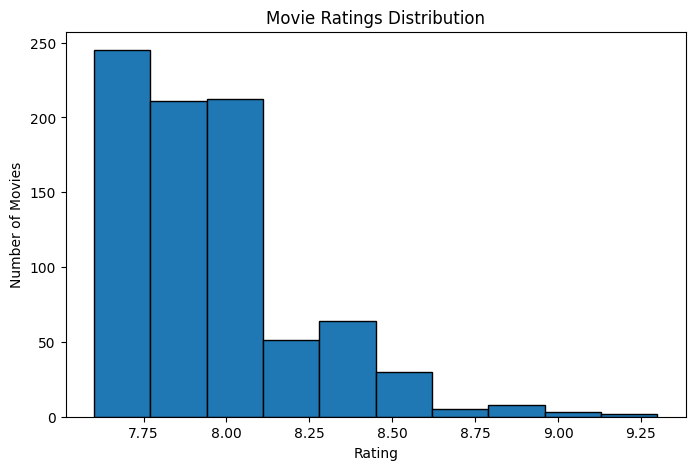

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['IMDB_Rating'], bins=10, edgecolor='black')
plt.title("Movie Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

Step 5: Plot Bar Chart

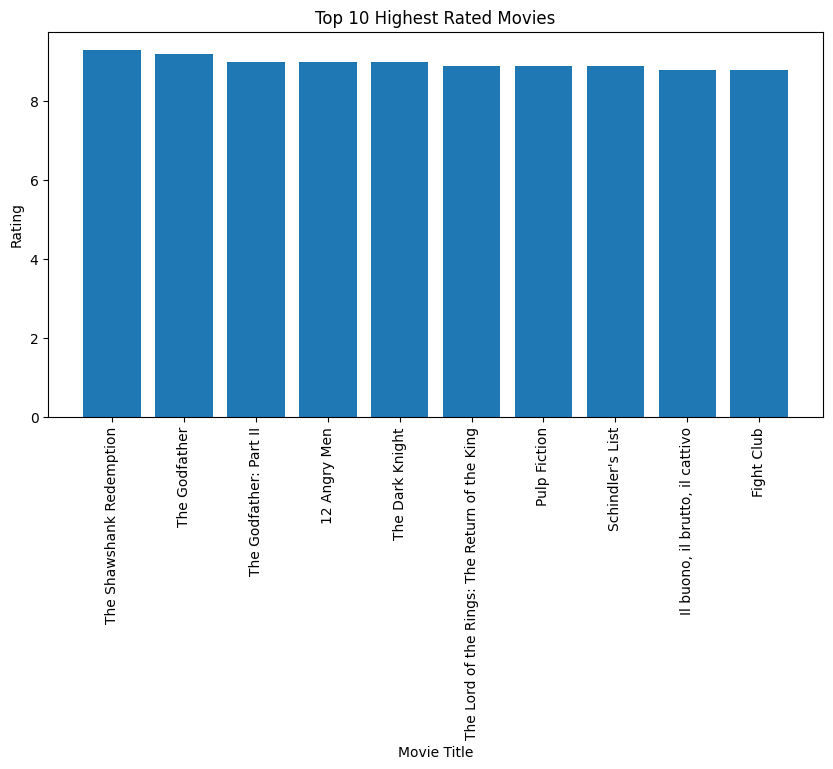

In [ ]:
top_rated = df.sort_values(by="IMDB_Rating", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_rated['Series_Title'], top_rated['IMDB_Rating'])
plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Rating")
plt.xticks(rotation=90)
plt.show()

Step 6: Plot Bar Chart

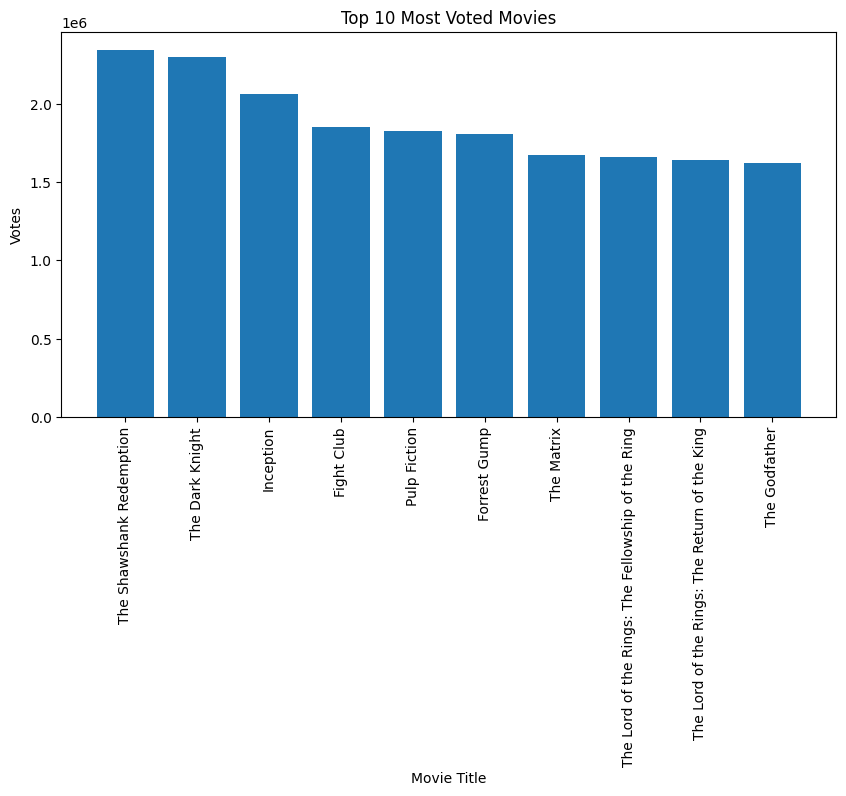

In [ ]:
most_voted = df.sort_values(by="No_of_Votes", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(most_voted['Series_Title'], most_voted['No_of_Votes'])
plt.title("Top 10 Most Voted Movies")
plt.xlabel("Movie Title")
plt.ylabel("Votes")
plt.xticks(rotation=90)
plt.show()

Step 7: Plot Line Chart

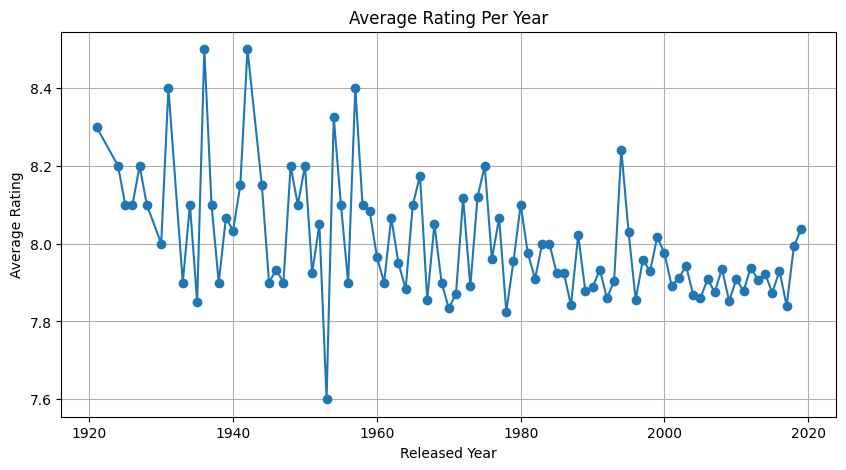

In [ ]:
df['IMDB_Rating'] = pd.to_numeric(df['IMDB_Rating'], errors='coerce')
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

df = df.dropna(subset=['IMDB_Rating', 'Released_Year'])

avg_rating_year = df.groupby("Released_Year")['IMDB_Rating'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_rating_year.index, avg_rating_year.values, marker='o')
plt.title("Average Rating Per Year")
plt.xlabel("Released Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()

Step 8: Plot Movies Count Per Year

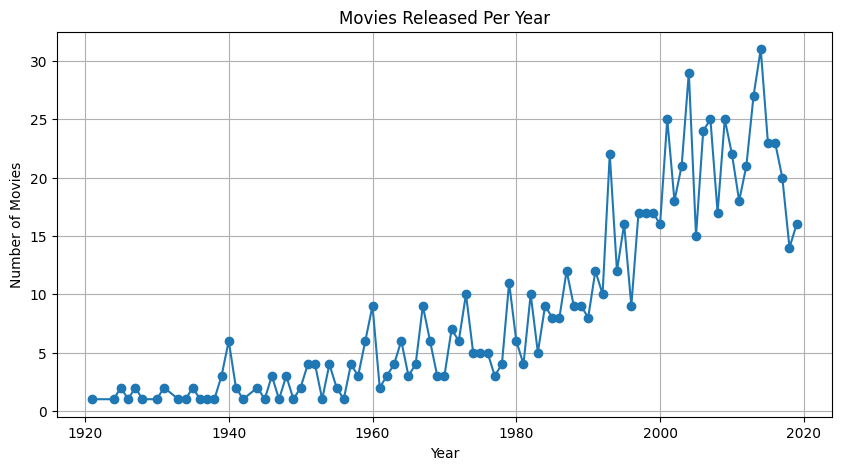

In [ ]:
movies_per_year = df['Released_Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o')
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True)
plt.show()

Step 9: Scatter Plot

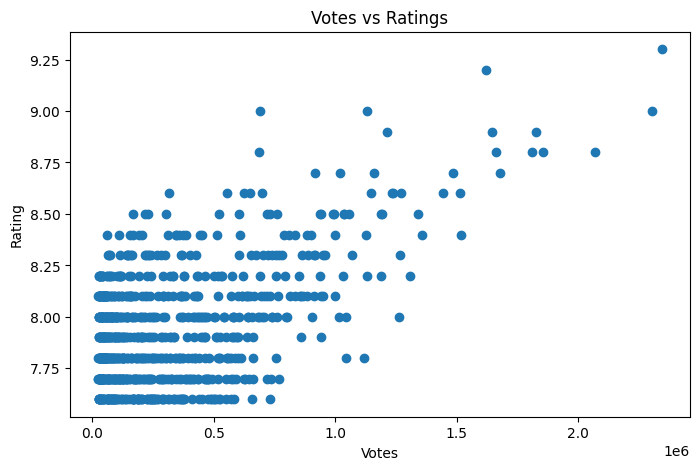

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['No_of_Votes'], df['IMDB_Rating'])
plt.title("Votes vs Ratings")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

Step 10: Genre Chart

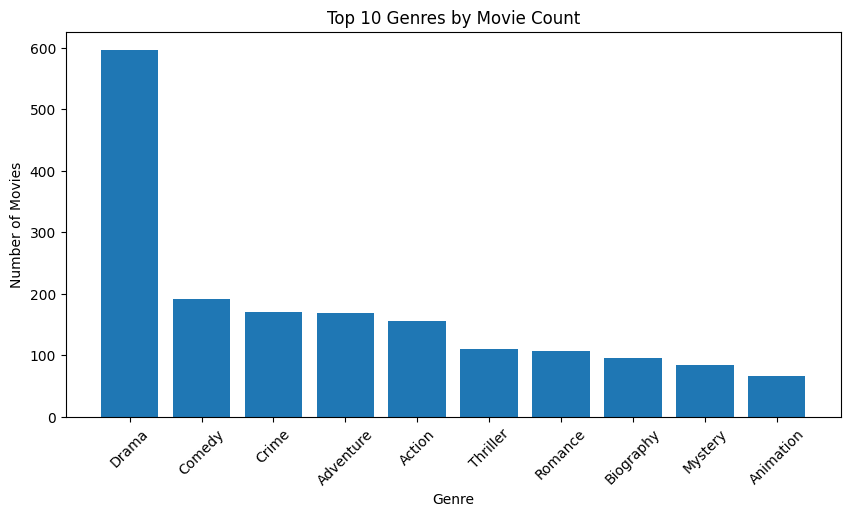

In [ ]:
df_genre = df.copy()
df_genre['Genre'] = df_genre['Genre'].str.split(",")
df_genre = df_genre.explode("Genre")
df_genre['Genre'] = df_genre['Genre'].str.strip()

top_genres = df_genre['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(top_genres.index, top_genres.values)
plt.title("Top 10 Genres by Movie Count")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

Step 11: Genre Rating Chart

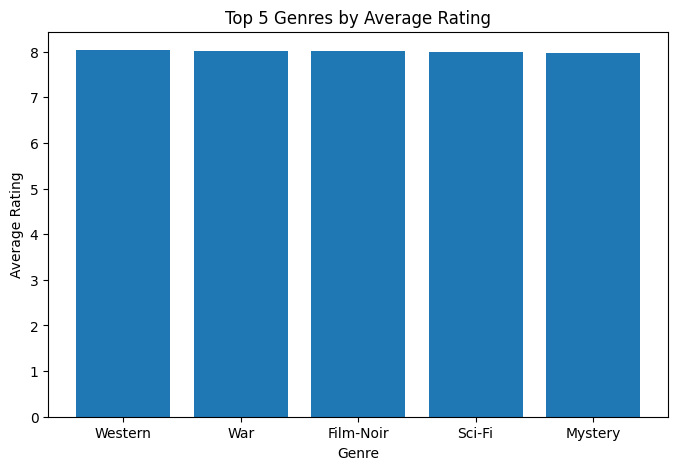

In [ ]:
genre_avg_rating = df_genre.groupby("Genre")['IMDB_Rating'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.bar(genre_avg_rating.index, genre_avg_rating.values)
plt.title("Top 5 Genres by Average Rating")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()